# Machine Failure Prediction Dashboard
# Dataset: AI4I 2020 Predictive Maintenance Dataset
# Goal: Predict machine failure risk and failure type, then trigger warnings/notifications.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# If xgboost is not installed, run this once in a notebook cell:
# !pip install xgboost
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("xgboost is not installed. Random Forest and Gradient Boosting will still work.")

In [2]:
df = pd.read_csv('ai4i2020.csv')

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nSummary statistics:\n", df.describe(include="all"))

Shape: (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Data types:
 UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Missing values:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine f

In [4]:
target_cols = ["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
df[target_cols].head(10)

,Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
5,0,0,0,0,0,0
6,0,0,0,0,0,0
7,0,0,0,0,0,0
8,0,0,0,0,0,0
9,0,0,0,0,0,0


In [5]:
# Drop ID columns if present
drop_cols = [col for col in ["UDI", "Product ID"] if col in df.columns]
df_clean = df.drop(columns=drop_cols).copy()

# Check unique values in Type
print("Unique values in Type:", df_clean["Type"].unique())
print("\nNull values after cleaning:\n", df_clean.isna().sum())

Unique values in Type: <StringArray>
['M', 'L', 'H']
Length: 3, dtype: str

Null values after cleaning:
 Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


Machine failure distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure percentage:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


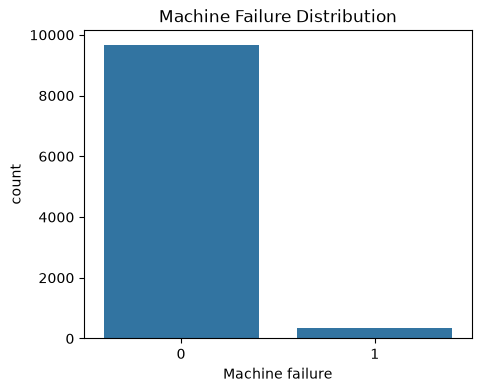

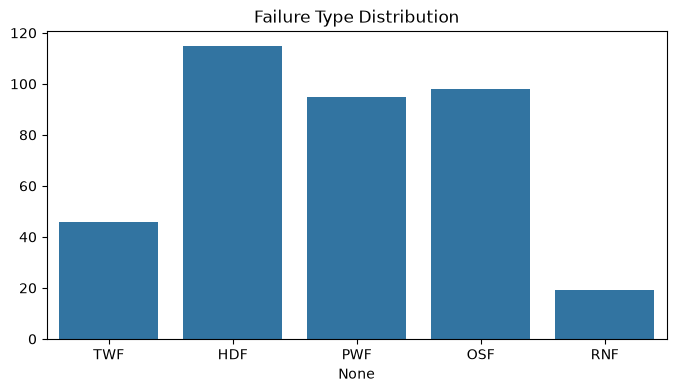

In [6]:
print("Machine failure distribution:")
print(df_clean["Machine failure"].value_counts())
print("\nMachine failure percentage:")
print(df_clean["Machine failure"].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 4))
sns.countplot(x="Machine failure", data=df_clean)
plt.title("Machine Failure Distribution")
plt.show()

plt.figure(figsize=(8, 4))
failure_type_counts = df_clean[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum()
sns.barplot(x=failure_type_counts.index, y=failure_type_counts.values)
plt.title("Failure Type Distribution")
plt.show()

In [7]:
X1 = df_clean.drop(columns=[
    "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"
])
y1 = df_clean["Machine failure"]

print("X1 shape:", X1.shape)
print("y1 shape:", y1.shape)
X1.head()

X1 shape: (10000, 6)
y1 shape: (10000,)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [8]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

print("Train shape:", X1_train.shape, y1_train.shape)
print("Test shape :", X1_test.shape, y1_test.shape)

Train shape: (8000, 6) (8000,)
Test shape : (2000, 6) (2000,)


In [9]:
categorical_features_1 = ["Type"]
numerical_features_1 = [c for c in X1.columns if c not in categorical_features_1]

preprocessor_1 = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features_1),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features_1)
    ],
    remainder="drop"
)

In [10]:
# Compute class imbalance weight for XGBoost if available
pos = (y1_train == 1).sum()
neg = (y1_train == 0).sum()
scale_pos_weight = neg / max(pos, 1)

model1_candidates = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )
}

if XGB_AVAILABLE:
    model1_candidates["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    )

model1_pipelines = {}
model1_predictions = {}

for name, model in model1_candidates.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor_1),
        ("model", model)
    ])
    pipe.fit(X1_train, y1_train)
    
    y1_pred = pipe.predict(X1_test)
    y1_prob = pipe.predict_proba(X1_test)[:, 1]
    
    model1_pipelines[name] = pipe
    model1_predictions[name] = {
        "y_pred": y1_pred,
        "y_prob": y1_prob
    }

print("Model 1 training completed.")

Model 1 training completed.


               Model  Accuracy  Precision    Recall        F1   ROC-AUC
2            XGBoost    0.9765   0.620690  0.794118  0.696774  0.971266
1  Gradient Boosting    0.9870   0.903846  0.691176  0.783333  0.967254
0      Random Forest    0.9790   0.709677  0.647059  0.676923  0.959616

Best Model 1: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.62      0.79      0.70        68

    accuracy                           0.98      2000
   macro avg       0.81      0.89      0.84      2000
weighted avg       0.98      0.98      0.98      2000



<Figure size 500x400 with 0 Axes>

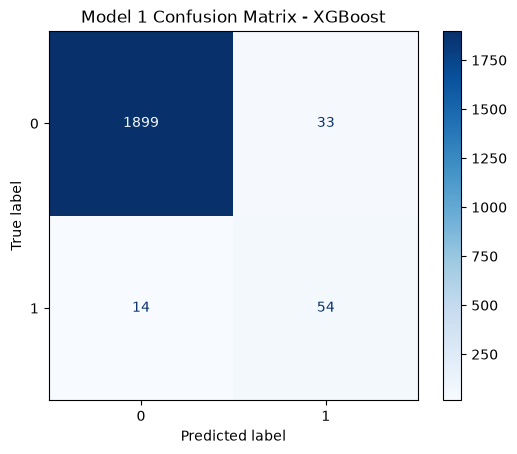

In [12]:
model1_results = []

for name in model1_predictions:
    y_pred = model1_predictions[name]["y_pred"]
    y_prob = model1_predictions[name]["y_prob"]
    
    model1_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y1_test, y_pred),
        "Precision": precision_score(y1_test, y_pred, zero_division=0),
        "Recall": recall_score(y1_test, y_pred, zero_division=0),
        "F1": f1_score(y1_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y1_test, y_prob)
    })

model1_results_df = pd.DataFrame(model1_results)
model1_results_df = model1_results_df.sort_values(
    by=["Recall", "F1", "ROC-AUC"],
    ascending=False
)

print(model1_results_df)

best_model1_name = model1_results_df.iloc[0]["Model"]
best_model1_pipeline = model1_pipelines[best_model1_name]

print("\nBest Model 1:", best_model1_name)

best_y1_pred = model1_predictions[best_model1_name]["y_pred"]
best_y1_prob = model1_predictions[best_model1_name]["y_prob"]

print("\nClassification Report:")
print(classification_report(y1_test, best_y1_pred, zero_division=0))

plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y1_test, best_y1_pred, cmap="Blues")
plt.title(f"Model 1 Confusion Matrix - {best_model1_name}")
plt.show()

In [13]:
# Failure probability for the whole test set
failure_probability_test = best_model1_pipeline.predict_proba(X1_test)[:, 1]

probability_df = X1_test.copy()
probability_df["Actual Failure"] = y1_test.values
probability_df["Predicted Failure"] = best_y1_pred
probability_df["Failure Probability"] = failure_probability_test

probability_df.head(10)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Actual Failure,Predicted Failure,Failure Probability
2997,L,300.5,309.8,1345,62.7,153,0,1,0.521781
4871,L,303.7,312.4,1513,40.1,135,0,0,0.000916
3858,L,302.5,311.4,1559,37.6,209,0,0,0.222638
951,H,295.6,306.3,1509,35.8,60,0,0,0.001686
6463,H,300.5,310.0,1358,60.4,102,0,0,0.071728
3264,H,301.3,310.1,1455,44.1,188,0,0,0.001384
4508,L,302.4,310.0,1426,46.6,102,0,0,0.083334
2100,M,299.3,309.3,1471,46.0,42,0,0,0.001093
7885,L,300.7,312.3,1590,36.3,93,0,0,0.000187
2421,L,298.9,308.2,2384,15.0,19,0,0,0.066255


In [14]:
def get_warning_status(prob):
    if prob < 0.30:
        return "Green - Healthy"
    elif prob < 0.60:
        return "Yellow - Monitor"
    elif prob < 0.80:
        return "Orange - Warning"
    else:
        return "Red - Critical"

probability_df["Status"] = probability_df["Failure Probability"].apply(get_warning_status)

probability_df[["Failure Probability", "Status"]].head(10)

,Failure Probability,Status
2997,0.521781,Yellow - Monitor
4871,0.000916,Green - Healthy
3858,0.222638,Green - Healthy
951,0.001686,Green - Healthy
6463,0.071728,Green - Healthy
3264,0.001384,Green - Healthy
4508,0.083334,Green - Healthy
2100,0.001093,Green - Healthy
7885,0.000187,Green - Healthy
2421,0.066255,Green - Healthy


In [15]:
failed_df = df_clean[df_clean["Machine failure"] == 1].copy()

failed_df["Failure Type"] = failed_df[["TWF", "HDF", "PWF", "OSF", "RNF"]].idxmax(axis=1)

failed_df[["Machine failure", "Failure Type"]].head(10)

,Machine failure,Failure Type
50,1,PWF
69,1,PWF
77,1,TWF
160,1,OSF
161,1,OSF
168,1,PWF
194,1,PWF
207,1,PWF
242,1,OSF
248,1,OSF


In [16]:
X2 = failed_df.drop(columns=[
    "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF", "Failure Type"
])

y2_raw = failed_df["Failure Type"]

label_encoder_2 = LabelEncoder()
y2 = label_encoder_2.fit_transform(y2_raw)

print("X2 shape:", X2.shape)
print("y2 classes:", label_encoder_2.classes_)

X2 shape: (339, 6)
y2 classes: ['HDF' 'OSF' 'PWF' 'TWF']


In [17]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print("Train shape:", X2_train.shape, y2_train.shape)
print("Test shape :", X2_test.shape, y2_test.shape)

Train shape: (271, 6) (271,)
Test shape : (68, 6) (68,)


In [18]:
categorical_features_2 = ["Type"]
numerical_features_2 = [c for c in X2.columns if c not in categorical_features_2]

preprocessor_2 = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features_2),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features_2)
    ],
    remainder="drop"
)

model2_candidates = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )
}

if XGB_AVAILABLE:
    model2_candidates["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="multi:softprob",
        num_class=len(label_encoder_2.classes_),
        eval_metric="mlogloss"
    )

model2_pipelines = {}
model2_predictions = {}

for name, model in model2_candidates.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor_2),
        ("model", model)
    ])
    pipe.fit(X2_train, y2_train)
    
    y2_pred = pipe.predict(X2_test)
    model2_pipelines[name] = pipe
    model2_predictions[name] = {"y_pred": y2_pred}

print("Model 2 training completed.")

Model 2 training completed.


               Model  Accuracy  Macro Precision  Macro Recall  Macro F1
2            XGBoost  0.882353         0.882786      0.862532  0.867085
1  Gradient Boosting  0.867647         0.881609      0.846907  0.856868
0      Random Forest  0.808824         0.817308      0.782513  0.791992

Best Model 2: XGBoost

Classification Report:
              precision    recall  f1-score   support

         HDF       0.85      1.00      0.92        23
         OSF       0.92      0.69      0.79        16
         PWF       0.94      0.94      0.94        18
         TWF       0.82      0.82      0.82        11

    accuracy                           0.88        68
   macro avg       0.88      0.86      0.87        68
weighted avg       0.89      0.88      0.88        68



<Figure size 600x500 with 0 Axes>

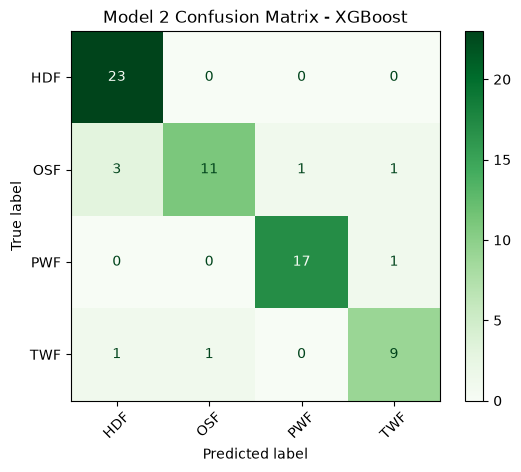

In [19]:
model2_results = []

for name in model2_predictions:
    y_pred = model2_predictions[name]["y_pred"]
    
    model2_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y2_test, y_pred),
        "Macro Precision": precision_score(y2_test, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y2_test, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y2_test, y_pred, average="macro", zero_division=0)
    })

model2_results_df = pd.DataFrame(model2_results)
model2_results_df = model2_results_df.sort_values(
    by=["Macro F1", "Macro Recall", "Accuracy"],
    ascending=False
)

print(model2_results_df)

best_model2_name = model2_results_df.iloc[0]["Model"]
best_model2_pipeline = model2_pipelines[best_model2_name]

print("\nBest Model 2:", best_model2_name)

best_y2_pred = model2_predictions[best_model2_name]["y_pred"]

print("\nClassification Report:")
print(classification_report(
    y2_test,
    best_y2_pred,
    target_names=label_encoder_2.classes_,
    zero_division=0
))

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y2_test,
    best_y2_pred,
    display_labels=label_encoder_2.classes_,
    cmap="Greens"
)
plt.title(f"Model 2 Confusion Matrix - {best_model2_name}")
plt.xticks(rotation=45)
plt.show()

In [20]:
sample_input = X1_test.iloc[[0]].copy()
sample_input

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
2997,L,300.5,309.8,1345,62.7,153


In [21]:
failure_prob = best_model1_pipeline.predict_proba(sample_input)[0, 1]
status = get_warning_status(failure_prob)

if failure_prob >= 0.60:
    pred_type_encoded = best_model2_pipeline.predict(sample_input)[0]
    pred_type = label_encoder_2.inverse_transform([pred_type_encoded])[0]
else:
    pred_type = "No Failure"

print("Failure Probability:", round(failure_prob, 4))
print("Status:", status)
print("Predicted Failure Type:", pred_type)

Failure Probability: 0.5218
Status: Yellow - Monitor
Predicted Failure Type: No Failure


In [22]:
result_summary = pd.DataFrame([{
    "Machine Status": status,
    "Failure Probability": round(failure_prob * 100, 2),
    "Predicted Failure Type": pred_type,
    "Notification": "Send Alert" if failure_prob >= 0.80 else "No Alert"
}])

result_summary

,Machine Status,Failure Probability,Predicted Failure Type,Notification
0,Yellow - Monitor,52.18,No Failure,No Alert


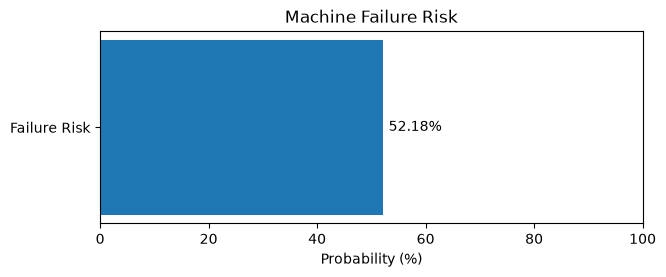

In [23]:
plt.figure(figsize=(7, 2.5))
plt.barh(["Failure Risk"], [failure_prob * 100])
plt.xlim(0, 100)
plt.xlabel("Probability (%)")
plt.title("Machine Failure Risk")
plt.text(failure_prob * 100 + 1, 0, f"{failure_prob*100:.2f}%", va="center")
plt.show()

In [24]:
print("Project completed successfully.")
print("Model 1 predicts machine failure risk.")
print("Model 2 predicts failure type when risk is high.")
print("The dashboard can use the probability score to trigger warnings and notifications.")

Project completed successfully.
Model 1 predicts machine failure risk.
Model 2 predicts failure type when risk is high.
The dashboard can use the probability score to trigger warnings and notifications.
